In [75]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [76]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [77]:

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0
X_train = np.expand_dims(X_train, axis=-1)
X_test  = np.expand_dims(X_test, axis=-1)

print(X_train.shape)
print(X_test.shape)


(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [78]:
X_train = tf.image.resize(X_train, [32,32]).numpy()
X_test  = tf.image.resize(X_test, [32,32]).numpy()

# Crear one-hot encoding NUEVAMENTE
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)


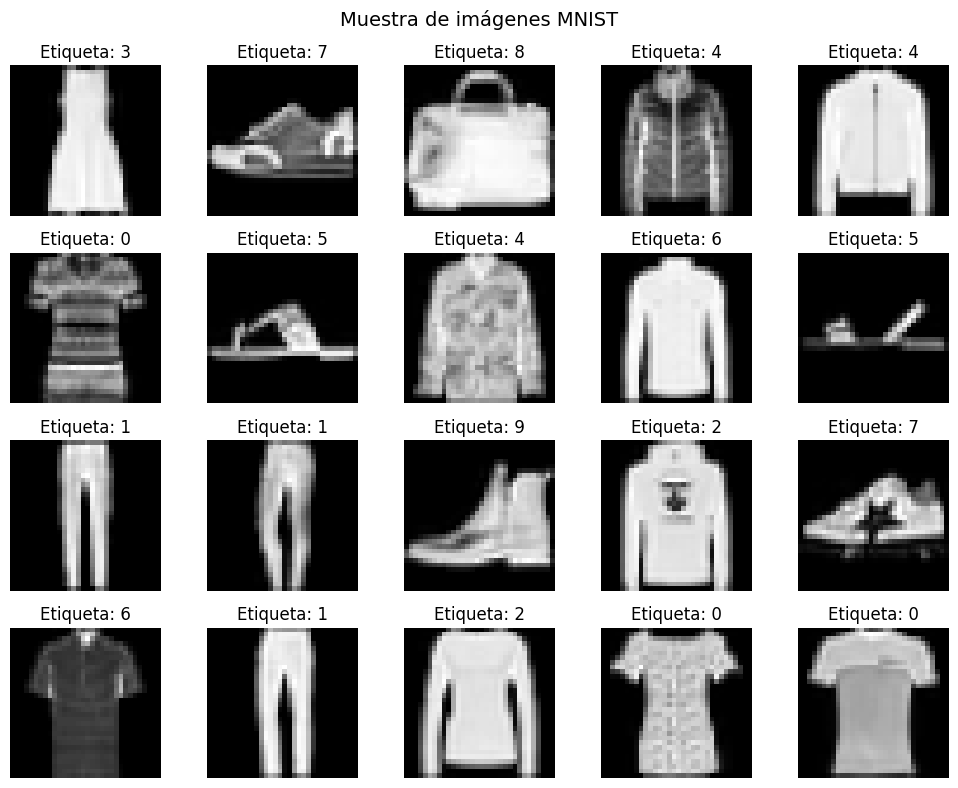

In [79]:
perm = np.random.permutation(len(X_train))[:20]

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[perm[i], :, :, 0], cmap='gray')
    ax.set_title(f'Etiqueta: {y_train[perm[i]]}')
    ax.axis('off')
plt.suptitle('Muestra de imágenes MNIST', fontsize=14)
plt.tight_layout()
plt.show()

In [83]:
def build_lenet5(input_shape=(32, 32, 1), num_classes=10):
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # C1 — convolution2dLayer(5,6,'Padding','same') + batchNorm + relu
        layers.Conv2D(6, kernel_size=5, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        # S2 — averagePooling2dLayer(2,'Stride',2)
        layers.AveragePooling2D(pool_size=2, strides=2),

        # C3 — convolution2dLayer(5,16) + batchNorm + relu
        layers.Conv2D(16, kernel_size=5, padding='valid'),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        # S4 — averagePooling2dLayer(2,'Stride',2)
        layers.AveragePooling2D(pool_size=2, strides=2),

        # C5 — convolution2dLayer(5,120) + relu
        layers.Conv2D(120, kernel_size=5, padding='valid'),
        layers.Activation('relu'),

        layers.Flatten(),

        # F6 — fullyConnectedLayer(84) + relu
        layers.Dense(84, activation='relu'),

        # Salida — fullyConnectedLayer(10) + softmax
        layers.Dense(num_classes, activation='softmax'),
    ], name='LeNet-5')

    return model

model = build_lenet5()
model.summary()

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 32, 32, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_12            │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_13            │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 2, 2, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 2, 2, 120)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 84)             │        40,404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,034 (359.51 KB)

 Trainable params: 91,990 (359.34 KB)

 Non-trainable params: 44 (176.00 B)

In [84]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [85]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8307 - loss: 0.4639 - val_accuracy: 0.8521 - val_loss: 0.4174
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8841 - loss: 0.3160 - val_accuracy: 0.8785 - val_loss: 0.3282
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9001 - loss: 0.2747 - val_accuracy: 0.8853 - val_loss: 0.3093
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9076 - loss: 0.2488 - val_accuracy: 0.8833 - val_loss: 0.3088
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9150 - loss: 0.2316 - val_accuracy: 0.9016 - val_loss: 0.2828
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9193 - loss: 0.2152 - val_accuracy: 0.9023 - val_loss: 0.2745
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9246 - loss: 0.2016 - val_accuracy: 0.8845 - val_loss: 0.3098
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9287 - loss: 0.1903 - val_accuracy: 

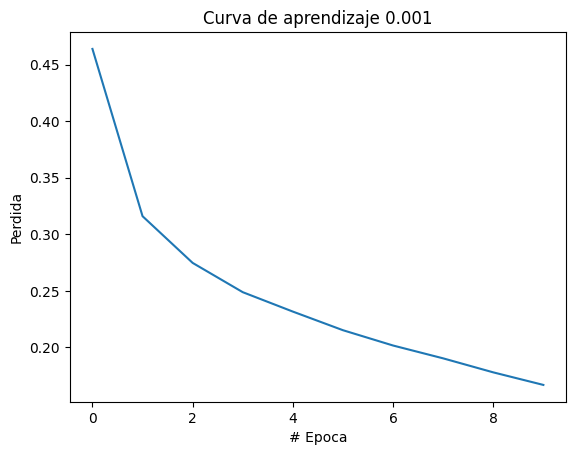

In [86]:
plt.xlabel("# Epoca")
plt.ylabel("Perdida")
plt.title("Curva de aprendizaje 0.001")
plt.plot(history.history["loss"])

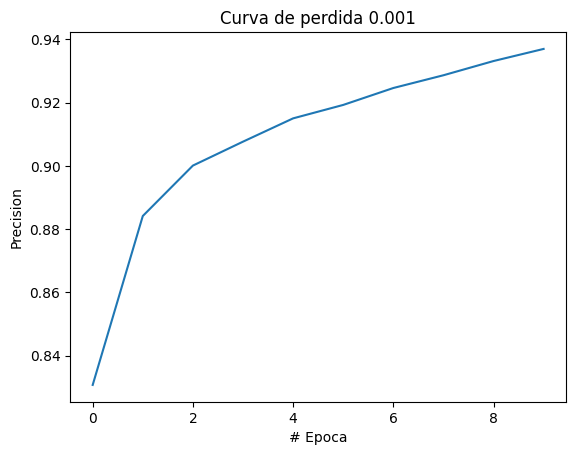

In [87]:
plt.xlabel("# Epoca")
plt.ylabel("Precision")
plt.title("Curva de perdida 0.001")
plt.plot(history.history["accuracy"])

In [88]:
# Predicciones
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Precisión
accuracy = np.mean(y_pred == y_test)
print(f'Precisión del modelo: {accuracy * 100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Precisión del modelo: 87.54%


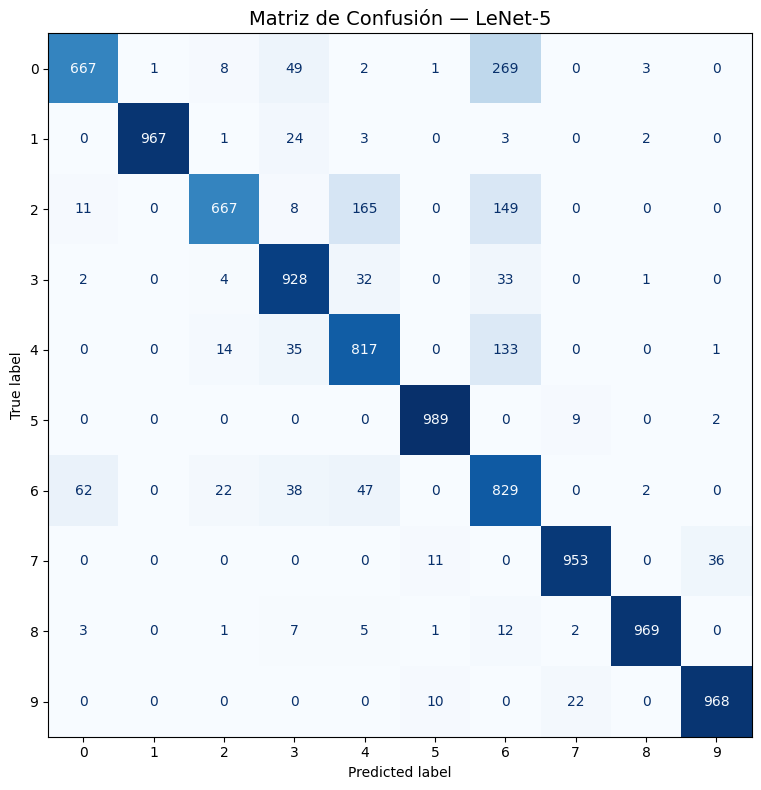

In [89]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(range(10)))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — LeNet-5', fontsize=14)
plt.tight_layout()
plt.show()

In [93]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
sample_image = X_test[1]
true_label   = y_test[1]

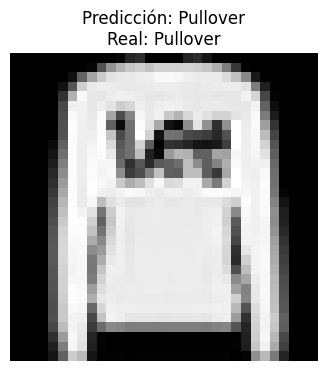

In [94]:

pred_probs = model.predict(
    sample_image[np.newaxis, ...],
    verbose=0
)

pred_label = np.argmax(pred_probs)
plt.figure(figsize=(4,4))

plt.imshow(
    sample_image[:, :, 0],
    cmap='gray'
)

plt.title(
    f'Predicción: {class_names[pred_label]}\n'
    f'Real: {class_names[true_label]}',
    fontsize=12
)

plt.axis('off')

plt.show()